In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from ddpg_td3_layernorm_lunar.ddpg import DDPG
from ddpg_td3_layernorm_lunar.replay_buffer import ReplayBuffer
from ddpg_td3_layernorm_lunar.run import run_policy
from ddpg_td3_layernorm_lunar.td3 import TD3

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Most of the following code is based on https://github.com/sfujim/td3

In [4]:
algo = DDPG
seed = 1
layer_normalization = True

In [17]:
results_dir = Path("../results")


def load_and_process_data(
    results_dir: Path, algo: DDPG | TD3, layer_normalization: bool, seeds: range | list
):
    steps = []
    evaluations = []
    biases = []
    for seed in seeds:
        x = np.load(
            results_dir / f"{algo.__name__}_seed_{seed}_ln_{layer_normalization}.npz"
        )
        steps.append(x["steps"])
        evaluations.append(x["evaluations"])
        biases.append(x["biases"])
    steps = np.stack(steps)
    evaluations = np.stack(evaluations)
    biases = np.stack(biases)

    # Process the data

    n_runs = len(seeds)
    # Remove the bottom and top 10% performances at each step
    n_trim = int(n_runs * 0.1)

    sorted_evaluations = np.sort(evaluations)
    sorted_biases = np.sort(biases)

    # Remove bottom and top 10%
    if n_trim > 0:
        trimmed_evaluations = sorted_evaluations[n_trim:-n_trim]
        trimmed_biases = sorted_biases[n_trim:-n_trim]
    else:
        trimmed_evaluations = sorted_evaluations
        trimmed_biases = sorted_biases

    mean_evaluations = trimmed_evaluations.mean(0)
    mean_biases = trimmed_biases.mean(0)

    std_evaluations = trimmed_evaluations.std(0)
    std_biases = trimmed_biases.std(0)

    steps = steps[0]  # WARNING: We assume all the steps are the same
    return steps[0], mean_evaluations, std_evaluations, mean_biases, std_biases


steps, evaluations, biases = load_and_process_data(results_dir, DDPG, False, range(20))

ValueError: too many values to unpack (expected 3)

In [ ]:
import numpy as np


def trimmed_stats(runs, trim=0.1):
    n_runs = runs.shape[0]
    n_trim = int(n_runs * trim)

    # Sort runs independently at each timestep
    sorted_runs = np.sort(runs, axis=0)

    # Remove bottom and top 10%
    if n_trim > 0:
        trimmed = sorted_runs[n_trim:-n_trim]
    else:
        trimmed = sorted_runs

    mean = trimmed.mean(axis=0)
    std = trimmed.std(axis=0)

    return mean, std

In [4]:
# algo = DDPG
# seed = 1
# layer_normalization = True

res = {}
for algo in [DDPG, TD3]:
    for layer_normalization in [False, True]:
        steps = []
        evaluations = []
        biases = []
        for seed in range(20):
            x = np.load(
                f"../results/{algo.__name__}_seed_{seed}_ln_{layer_normalization}.npz"
            )
            steps.append(x["steps"])
            evaluations.append(x["evaluations"])
            biases.append(x["biases"])
        res[f"{algo.__name__}_ln_{layer_normalization}"] = (steps, evaluations, biases)

In [ ]:
ass

{'DDPG_ln_False': ([array([     0,   5000,  10000,  15000,  20000,  25000,  30000,  35000,
           40000,  45000,  50000,  55000,  60000,  65000,  70000,  75000,
           80000,  85000,  90000,  95000, 100000, 105000, 110000, 115000,
          120000, 125000, 130000, 135000, 140000, 145000, 150000, 155000,
          160000, 165000, 170000, 175000, 180000, 185000, 190000, 195000,
          200000, 205000, 210000, 215000, 220000, 225000, 230000, 235000,
          240000, 245000, 250000, 255000, 260000, 265000, 270000, 275000,
          280000, 285000, 290000, 295000, 300000, 305000, 310000, 315000,
          320000, 325000, 330000, 335000, 340000, 345000, 350000, 355000,
          360000, 365000, 370000, 375000, 380000, 385000, 390000, 395000,
          400000, 405000, 410000, 415000, 420000, 425000, 430000, 435000,
          440000, 445000, 450000, 455000, 460000, 465000, 470000, 475000,
          480000, 485000, 490000, 495000, 500000]),
   array([     0,   5000,  10000,  15000,  

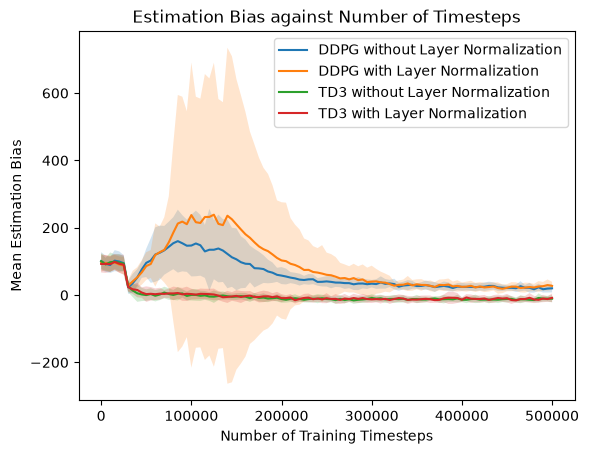

In [98]:
plt.title("Estimation Bias against Number of Timesteps")
for algo in [DDPG, TD3]:
    for layer_normalization in [False, True]:
        x = np.stack(res[f"{algo.__name__}_ln_{layer_normalization}"][0]).mean(0)
        y = np.stack(res[f"{algo.__name__}_ln_{layer_normalization}"][2]).mean(0)
        y_std = np.stack(res[f"{algo.__name__}_ln_{layer_normalization}"][2]).std(0)
        plt.plot(
            x,
            y,
            label=f"{algo.__name__} {'with' if layer_normalization else 'without'} Layer Normalization",
        )
        plt.fill_between(x, y - y_std, y + y_std, alpha=0.2)
plt.xlabel("Number of Training Timesteps")
plt.ylabel("Mean Estimation Bias")
plt.legend()
plt.show()

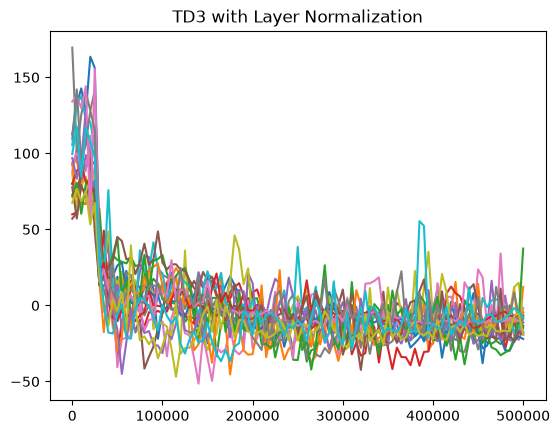

In [103]:
plt.title(
    f"{algo.__name__} {'with' if layer_normalization else 'without'} Layer Normalization"
)
for seed in range(20):
    x = np.load(f"../results/{algo.__name__}_seed_{seed}_ln_{layer_normalization}.npz")
    steps = x["steps"]
    evaluations = x["evaluations"]
    biases = x["biases"]

    plt.plot(steps, biases)
plt.show()

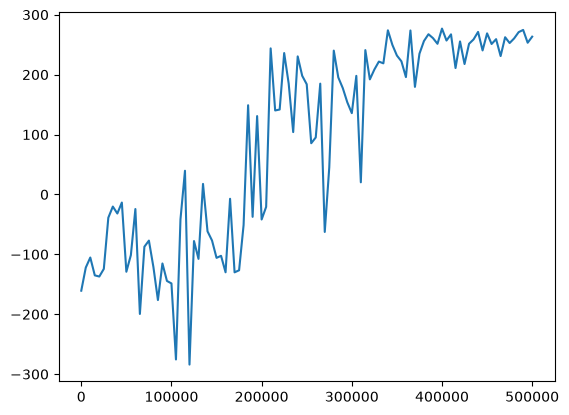

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")